# Task 1: Credit Scoring Model

**Objective:** Predict an individual's creditworthiness using past financial data.
**Approach:** Classification algorithms — Logistic Regression, Decision Tree, Random Forest.
**Dataset:** UCI Statlog (German Credit Data) — 1000 applicants, 20 attributes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load & decode the UCI German Credit dataset

The raw file uses coded categorical values (e.g. `A11`, `A34`) — we decode these into readable labels.

In [2]:
cols = ["checking_account", "duration_months", "credit_history", "purpose", "credit_amount",
        "savings_account", "employment_since", "installment_rate_pct", "personal_status_sex",
        "other_debtors", "present_residence_since", "property", "age", "other_installment_plans",
        "housing", "existing_credits", "job", "num_dependents", "telephone", "foreign_worker",
        "target"]
df = pd.read_csv("data/german_credit.csv", names=cols)

maps = {
    "checking_account": {"A11": "< 0 DM", "A12": "0-200 DM", "A13": ">= 200 DM", "A14": "no account"},
    "credit_history": {
        "A30": "no credits/all paid", "A31": "all credits paid (this bank)",
        "A32": "existing credits paid duly", "A33": "delay in past",
        "A34": "critical/other credits existing"
    },
    "purpose": {
        "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment",
        "A43": "radio/TV", "A44": "domestic appliances", "A45": "repairs",
        "A46": "education", "A47": "vacation", "A48": "retraining",
        "A49": "business", "A410": "other"
    },
    "savings_account": {
        "A61": "< 100 DM", "A62": "100-500 DM", "A63": "500-1000 DM",
        "A64": ">= 1000 DM", "A65": "unknown/none"
    },
    "employment_since": {
        "A71": "unemployed", "A72": "< 1 year", "A73": "1-4 years",
        "A74": "4-7 years", "A75": ">= 7 years"
    },
    "personal_status_sex": {
        "A91": "male:divorced/separated", "A92": "female:divorced/separated/married",
        "A93": "male:single", "A94": "male:married/widowed", "A95": "female:single"
    },
    "other_debtors": {"A101": "none", "A102": "co-applicant", "A103": "guarantor"},
    "property": {
        "A121": "real estate", "A122": "building society/life insurance",
        "A123": "car/other", "A124": "unknown/none"
    },
    "other_installment_plans": {"A141": "bank", "A142": "stores", "A143": "none"},
    "housing": {"A151": "rent", "A152": "own", "A153": "for free"},
    "job": {
        "A171": "unemployed/unskilled-nonresident", "A172": "unskilled-resident",
        "A173": "skilled employee", "A174": "management/self-employed/highly-qualified"
    },
    "telephone": {"A191": "none", "A192": "yes"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}
for col, mapping in maps.items():
    df[col] = df[col].map(mapping)

df["target"] = df["target"].map({1: 1, 2: 0})  # 1 = good, 0 = bad
df.head()

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,< 0 DM,6,critical/other credits existing,radio/TV,1169,unknown/none,>= 7 years,4,male:single,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,1
1,0-200 DM,48,existing credits paid duly,radio/TV,5951,< 100 DM,1-4 years,2,female:divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,0
2,no account,12,critical/other credits existing,education,2096,< 100 DM,4-7 years,2,male:single,none,...,real estate,49,none,own,1,unskilled-resident,2,none,yes,1
3,< 0 DM,42,existing credits paid duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male:single,guarantor,...,building society/life insurance,45,none,for free,1,skilled employee,2,none,yes,1
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1-4 years,3,male:single,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,0


## 2. Feature engineering from financial history

In [3]:
df["credit_per_month"] = df["credit_amount"] / df["duration_months"]
df["debt_burden_score"] = df["credit_amount"] * df["installment_rate_pct"] / 100
df["age_group"] = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 100],
                          labels=["<=25", "26-35", "36-45", "46-55", "56+"]).astype(str)
df["is_long_high_amount"] = (
    (df["duration_months"] > df["duration_months"].median()) &
    (df["credit_amount"] > df["credit_amount"].median())
).astype(int)
df["has_both_accounts"] = (
    (df["checking_account"] != "no account") &
    (df["savings_account"] != "unknown/none")
).astype(int)

NUMERIC_FEATURES = [
    "duration_months", "credit_amount", "installment_rate_pct",
    "present_residence_since", "age", "existing_credits", "num_dependents",
    "credit_per_month", "debt_burden_score", "is_long_high_amount", "has_both_accounts"
]
CATEGORICAL_FEATURES = [
    "checking_account", "credit_history", "purpose", "savings_account", "employment_since",
    "personal_status_sex", "other_debtors", "property", "other_installment_plans",
    "housing", "job", "telephone", "foreign_worker", "age_group"
]

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["target"]
print("Samples:", X.shape[0], " Class balance:\n", y.value_counts())

Samples: 1000  Class balance:
 target
1    700
0    300
Name: count, dtype: int64


## 3. Train/test split + preprocessing pipeline

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=10, class_weight="balanced", random_state=RANDOM_STATE),
}

## 4. Train & evaluate all models

In [5]:
results, fitted_pipelines = [], {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fitted_pipelines[name] = pipe
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, digits=3, target_names=["Bad Credit", "Good Credit"]))

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.round(3)


--- Logistic Regression ---
              precision    recall  f1-score   support

  Bad Credit      0.482     0.683     0.566        60
 Good Credit      0.835     0.686     0.753       140

    accuracy                          0.685       200
   macro avg      0.659     0.685     0.659       200
weighted avg      0.729     0.685     0.697       200


--- Decision Tree ---
              precision    recall  f1-score   support

  Bad Credit      0.404     0.633     0.494        60
 Good Credit      0.792     0.600     0.683       140

    accuracy                          0.610       200
   macro avg      0.598     0.617     0.588       200
weighted avg      0.676     0.610     0.626       200




--- Random Forest ---
              precision    recall  f1-score   support

  Bad Credit      0.564     0.517     0.539        60
 Good Credit      0.800     0.829     0.814       140

    accuracy                          0.735       200
   macro avg      0.682     0.673     0.677       200
weighted avg      0.729     0.735     0.732       200



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.735,0.800,0.829,0.814,0.775
1,Logistic Regression,0.685,0.835,0.686,0.753,0.757
2,Decision Tree,0.610,0.792,0.600,0.683,0.604


## 5. Confusion matrices

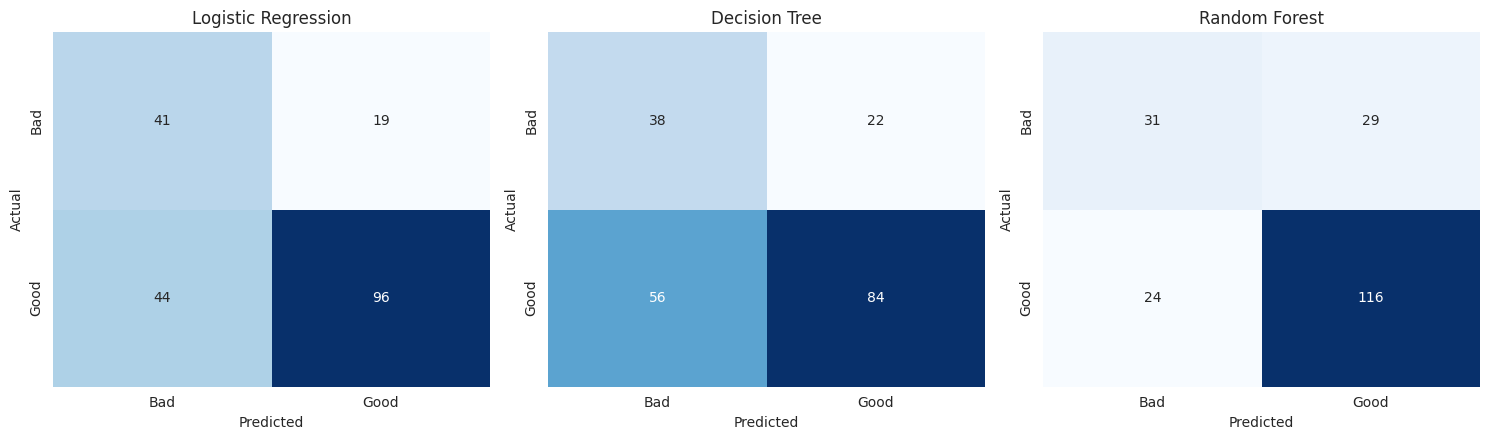

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

## 6. ROC curves

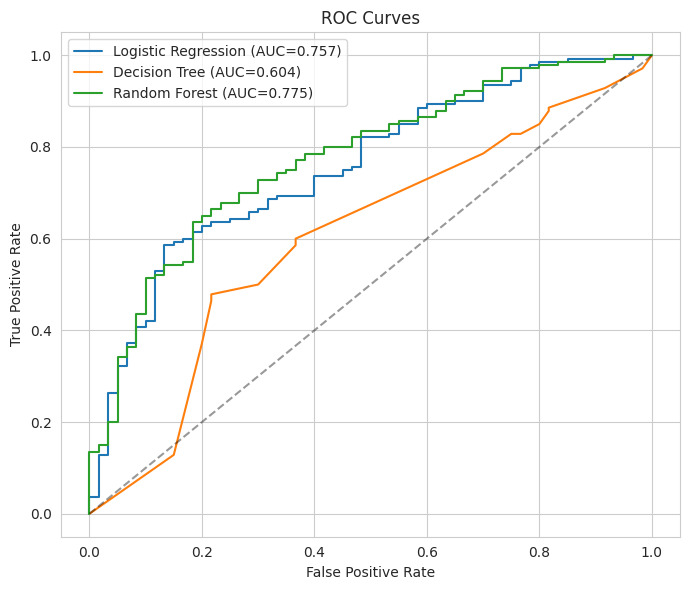

In [7]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(); plt.tight_layout(); plt.show()

## 7. Feature importance (Random Forest)

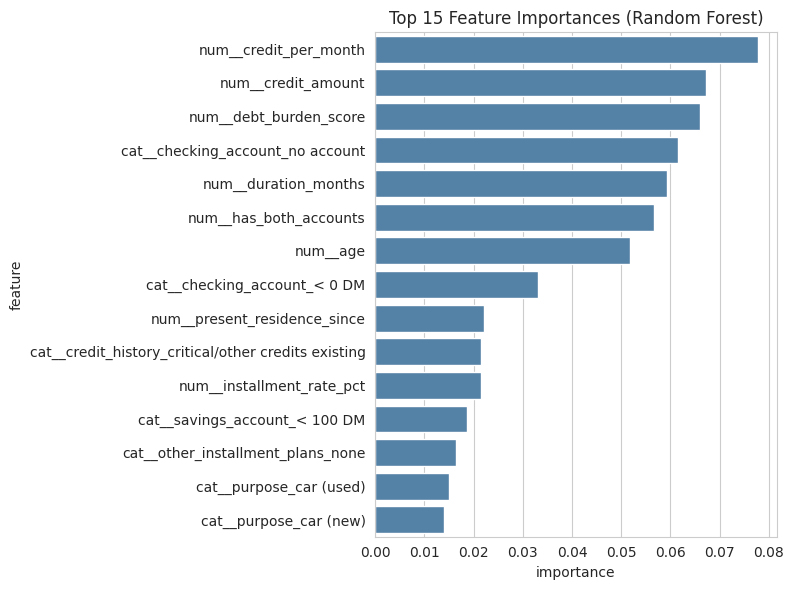

In [8]:
rf_pipe = fitted_pipelines["Random Forest"]
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, y="feature", x="importance", color="steelblue")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout(); plt.show()

## 8. Conclusion

- **Random Forest** performs best overall (highest ROC-AUC and F1-score), handling the
  imbalanced classes and non-linear feature interactions better than the other two.
- **Logistic Regression** has the highest precision on "Good Credit" but misses more
  actual bad-credit cases (lower recall on "Bad Credit") — riskier for a lender.
- **Decision Tree** (single tree, unconstrained depth aside from `max_depth=6`) is the
  weakest here — a known tendency to overfit / be less stable than an ensemble.
- Checking account status, credit amount, loan duration, and credit history are
  consistently the strongest predictors — matching real-world credit scoring intuition.